<a href="https://colab.research.google.com/github/Pramodsingh317/Student-Exam-Score-Predictor/blob/main/Student_Exam_Score_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[SUCCESS] Generated synthetic dataset: 'data/student_exam_data.csv'

Executing Model Training Mode...


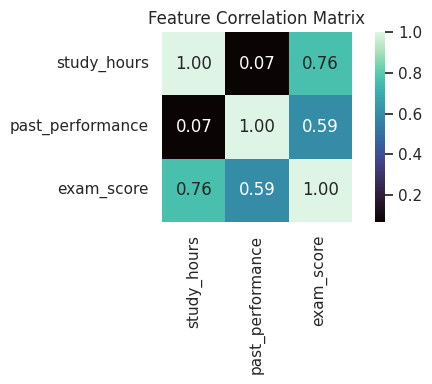


--- Linear Regression ---
MAE: 3.64
R²: 0.89

--- Logistic Regression ---
Accuracy: 80.00%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.80      1.00      0.89        80

    accuracy                           0.80       100
   macro avg       0.40      0.50      0.44       100
weighted avg       0.64      0.80      0.71       100



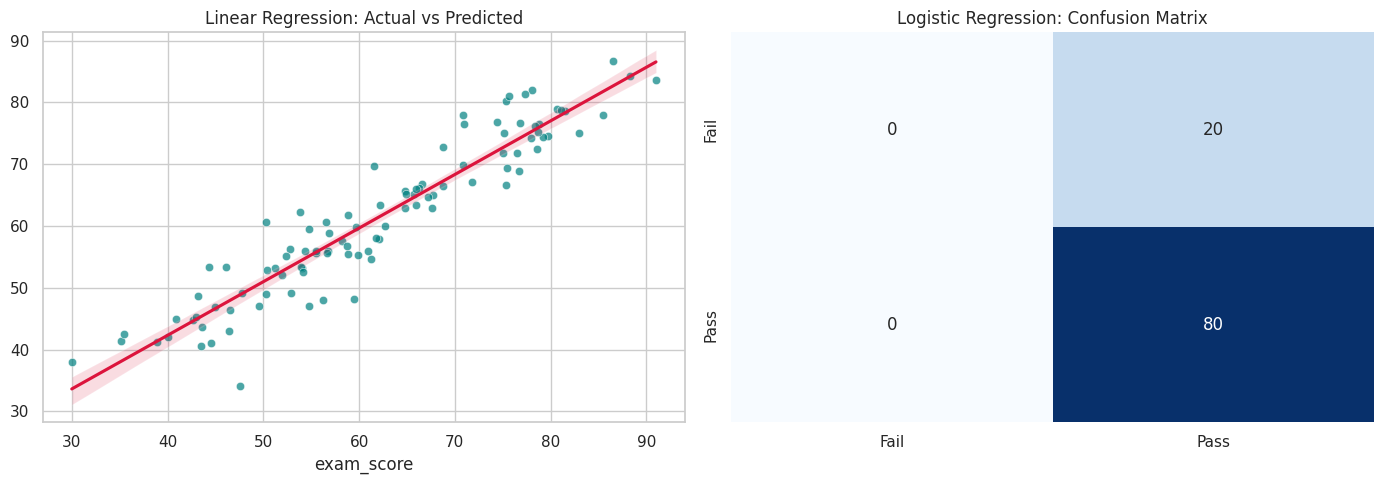

In [ ]:
import os
import datetime
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix

# --- CONFIGURATION & DIRECTORIES ---
DIR_DATA = "data"
DIR_MODELS = "models"
DIR_LOGS = "logs_and_meta"

for folder in [DIR_DATA, DIR_MODELS, DIR_LOGS]:
    os.makedirs(folder, exist_ok=True)

PATH_LINEAR_MODEL = os.path.join(DIR_MODELS, 'linear_model.pkl')
PATH_LOGISTIC_MODEL = os.path.join(DIR_MODELS, 'logistic_model.pkl')
PATH_SCALER = os.path.join(DIR_MODELS, 'scaler.pkl')

PASS_THRESHOLD = 50

# --- DATA GENERATION MODULE ---
def generate_synthetic_data(num_students=500, base_filename="student_exam_data.csv"):
    np.random.seed(42)
    study_hours = np.random.uniform(1.0, 10.0, size=num_students)
    past_performance = np.clip(np.random.normal(loc=70, scale=12, size=num_students), 0, 100)

    noise = np.random.normal(loc=0, scale=5, size=num_students)
    exam_score = np.clip((study_hours * 3.5) + (past_performance * 0.6) + noise, 0, 100)

    df = pd.DataFrame({
        'study_hours': np.round(study_hours, 1),
        'past_performance': np.round(past_performance, 1),
        'exam_score': np.round(exam_score, 1)
    })

    # Save target updated directly to data directory path
    full_path = os.path.join(DIR_DATA, base_filename)
    df.to_csv(full_path, index=False)
    print(f"[SUCCESS] Generated synthetic dataset: '{full_path}'")
    return full_path

# --- AUXILIARY UTILITIES ---
def _handle_class_imbalance(df):
    class_counts = df['pass_fail'].value_counts()
    mock_data = {
        0: {'study_hours': 0.5, 'past_performance': 15.0, 'exam_score': 20.0, 'pass_fail': 0},
        1: {'study_hours': 10.0, 'past_performance': 95.0, 'exam_score': 85.0, 'pass_fail': 1}
    }
    for cls, mock_row in mock_data.items():
        if class_counts.get(cls, 0) < 2:
            df = pd.concat([df, pd.DataFrame([mock_row])], ignore_index=True)
    return df

def _evaluate_and_visualize(linear_model, logistic_model, scaler, X_test_scaled, y_test_reg, y_test_clf, original_shape):
    y_pred_reg = linear_model.predict(X_test_scaled)
    y_pred_clf = logistic_model.predict(X_test_scaled)

    print(f"\n--- Linear Regression ---\nMAE: {mean_absolute_error(y_test_reg, y_pred_reg):.2f}\nR²: {r2_score(y_test_reg, y_pred_reg):.2f}")
    print(f"\n--- Logistic Regression ---\nAccuracy: {accuracy_score(y_test_clf, y_pred_clf) * 100:.2f}%")
    print(classification_report(y_test_clf, y_pred_clf, zero_division=0))

    joblib.dump(linear_model, PATH_LINEAR_MODEL)
    joblib.dump(logistic_model, PATH_LOGISTIC_MODEL)
    joblib.dump(scaler, PATH_SCALER)

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    with open(os.path.join(DIR_LOGS, f"env_freeze_{timestamp}.txt"), "w") as f:
        f.write(f"Pipeline executed on: {datetime.datetime.now()}\nDataset Shape: {original_shape}\n")

    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    sns.scatterplot(x=y_test_reg, y=y_pred_reg, color="teal", alpha=0.7, ax=ax1)
    sns.regplot(x=y_test_reg, y=y_pred_reg, scatter=False, color="crimson", ax=ax1)
    ax1.set_title("Linear Regression: Actual vs Predicted")

    cm = confusion_matrix(y_test_clf, y_pred_clf)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'], ax=ax2)
    ax2.set_title("Logistic Regression: Confusion Matrix")
    plt.tight_layout()
    plt.show()

# --- BULK PREDICTION MODULE ---
def run_bulk_prediction(df, original_path):
    if not (os.path.exists(PATH_LINEAR_MODEL) and os.path.exists(PATH_SCALER)):
        print(f"[CRITICAL ERROR] Untrained workspace. Train models with an 'exam_score' column first.")
        return

    print("\nExecuting Bulk Prediction Mode...")
    loaded_linear = joblib.load(PATH_LINEAR_MODEL)
    loaded_scaler = joblib.load(PATH_SCALER)

    X_new = df[['study_hours', 'past_performance']]
    X_new_scaled = loaded_scaler.transform(X_new)

    df['exam_score'] = np.round(np.clip(loaded_linear.predict(X_new_scaled), 0, 100), 2)
    df['pass_fail'] = (df['exam_score'] >= PASS_THRESHOLD).astype(int)

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    output_name = os.path.join(DIR_DATA, f"predicted_{timestamp}_{os.path.basename(original_path)}")
    df.to_csv(output_name, index=False)
    print(f"[SUCCESS] Saved calculated predictions out to: '{output_name}'")

# --- TRAINING PIPELINE ENGINE ---
def train_pipeline(csv_path):
    try:
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.lower()
    except Exception as e:
        print(f"[ERROR] Failed to read CSV: {e}")
        return

    required_inputs = ['study_hours', 'past_performance']
    if not all(col in df.columns for col in required_inputs):
        raise KeyError(f"CSV must contain features: {required_inputs}")

    if 'exam_score' not in df.columns:
        run_bulk_prediction(df, csv_path)
        return

    print("\nExecuting Model Training Mode...")
    df['pass_fail'] = (df['exam_score'] >= PASS_THRESHOLD).astype(int)
    df = _handle_class_imbalance(df)

    X = df[required_inputs]
    y_reg = df['exam_score']
    y_clf = df['pass_fail']

# --- FEATURE CORRELATION HEATMAP ---
    plt.figure(figsize=(6, 4))
    correlation_matrix = df[['study_hours', 'past_performance', 'exam_score']].corr()

    sns.heatmap(
      correlation_matrix,
      annot=True,
      cmap="mako",
      fmt=".2f",
      cbar=True,
      square=True
    )
    plt.title("Feature Correlation Matrix")
    plt.tight_layout()
    plt.show()


    X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
    _, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    linear_model = LinearRegression().fit(X_train_scaled, y_train_reg)
    logistic_model = LogisticRegression().fit(X_train_scaled, y_train_clf)

    _evaluate_and_visualize(linear_model, logistic_model, scaler, X_test_scaled, y_test_reg, y_test_clf, df.shape)

# Run pipeline infrastructure
generated_file = generate_synthetic_data()
train_pipeline(generated_file)


In [ ]:
import os
import joblib
import numpy as np
import pandas as pd

PATH_LINEAR_MODEL = os.path.join("models", 'linear_model.pkl')
PATH_LOGISTIC_MODEL = os.path.join("models", 'logistic_model.pkl')
PATH_SCALER = os.path.join("models", 'scaler.pkl')
PASS_THRESHOLD = 50

def run_interactive_inference():
    if not (os.path.exists(PATH_LINEAR_MODEL) and os.path.exists(PATH_LOGISTIC_MODEL) and os.path.exists(PATH_SCALER)):
        print("[ERROR] Production models missing. Run the pipeline in Cell 1 first.")
        return

    linear_model = joblib.load(PATH_LINEAR_MODEL)
    logistic_model = joblib.load(PATH_LOGISTIC_MODEL)
    scaler = joblib.load(PATH_SCALER)

    print("\n" + "="*50)
    print("PRODUCTION INFERENCE RUNTIME ACTIVE")
    print("="*50)

    while True:
        action = input("Press Enter to evaluate a profile (or type 'exit' to quit): ").strip().lower()
        if action == 'exit':
            print("Session closed.")
            break
        try:
            hours = float(input("Enter study_hours (0 to 12): "))
            past_perf = float(input("Enter past_performance score (0 to 100): "))

            if not (0 <= hours <= 24) or not (0 <= past_perf <= 100):
                print("[WARNING] Constraints violated. Hours must be realistic, scores bounded between 0-100.")
                continue

            features = pd.DataFrame([[hours, past_perf]], columns=['study_hours', 'past_performance'])
            features_scaled = scaler.transform(features)

            pred_score = np.clip(linear_model.predict(features_scaled), 0, 100)[0]
            status = "PASS" if pred_score >= PASS_THRESHOLD else "FAIL"

            print("-" * 45)
            print(f"Inputs: hours={hours}, performance={past_perf}")
            print(f"Predicted Score: {pred_score:.2f} / 100")
            print(f"Outcome Status : {status}")
            print("-" * 45 + "\n")

        except ValueError:
            print("[ERROR] Numeric parse failure. Check input values.\n")

run_interactive_inference()



PRODUCTION INFERENCE RUNTIME ACTIVE
Press Enter to evaluate a profile (or type 'exit' to quit): 
Enter study_hours (0 to 12): 8
Enter past_performance score (0 to 100): 84
---------------------------------------------
Inputs: hours=8.0, performance=84.0
Predicted Score: 79.17 / 100
Outcome Status : PASS
---------------------------------------------

Press Enter to evaluate a profile (or type 'exit' to quit): 
Enter study_hours (0 to 12): 3
Enter past_performance score (0 to 100): 47
---------------------------------------------
Inputs: hours=3.0, performance=47.0
Predicted Score: 38.33 / 100
Outcome Status : FAIL
---------------------------------------------

Press Enter to evaluate a profile (or type 'exit' to quit): exit
Session closed.
